# Baseline Comparisons
We compare the implementation of our Logistic Regression with two baselines: a **decision tree** with Gini impurity and **scikit-learn’s logistic regression** (solver `sag`, closest to our gradient-based trainer), plus the **custom** `LogisticRegressionModel` from `src`.

For **each model**, we run **Optuna** hyperparameter search on a stratified train/validation split, then refit on the full training set and evaluate on the held-out test set. We repeat this for **5 random seeds** (generated from a master seed) and for two scenarios: **all standardized features** and **PCA-reduced** features (`fit_best_pca_then_transform`). The tables at the end report **mean and standard deviation** of test metrics across seeds for each model and scenario.

In [1]:
import random
import warnings
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.logistic_regression import LogisticRegressionModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

from src.models.pca_reduction import fit_best_pca_then_transform
from src.utils import set_seed

/Users/romina/miniforge3/envs/torch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


In [3]:
# Preprocess data
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Training, tuning, and evaluation (full features + PCA)

The next cell runs the full experiment: Optuna tuning per model, 5 seeds, and both **full** and **PCA** scenarios. Later cells aggregate **mean ± std** over seeds for confusion matrices and per-class metrics.

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_SEEDS = 5
N_TRIALS = 30
VAL_FRACTION = 0.2
MASTER_SEED = 42

_rng = random.Random(MASTER_SEED)
SEEDS = [_rng.randint(1, 1000) for _ in range(N_SEEDS)]

metric_cols = [
    "test_accuracy",
    "test_macro_precision",
    "test_macro_recall",
    "test_macro_f1",
]


def _val_split(X, y, seed):
    return train_test_split(
        X, y, test_size=VAL_FRACTION, random_state=seed, stratify=y
    )


def _metric_dict(y_true, y_pred):
    return {
        "test_accuracy": float(accuracy_score(y_true, y_pred)),
        "test_macro_precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "test_macro_recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "test_macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
    }


def train_decision_tree(X_train, y_train, X_test, y_test, seed):
    
    clf = DecisionTreeClassifier(
        criterion="gini",
        random_state=seed,
    )
    clf.fit(X_train, y_train)
    bp = clf.get_params()
    pred = clf.predict(X_test)
    return _metric_dict(y_test, pred), pred, bp


def tune_sklearn_lr(X_train, y_train, X_test, y_test, seed):
    X_tr, X_val, y_tr, y_val = _val_split(X_train, y_train, seed)

    def objective(trial: optuna.Trial) -> float:
        C = trial.suggest_float("C", 1e-3, 100.0, log=True)
        max_iter = trial.suggest_int("max_iter", 500, 10000)
        clf = SklearnLogisticRegression(
            solver="sag",
            C=C,
            max_iter=max_iter,
            random_state=seed,
        )
        clf.fit(X_tr, y_tr)
        val_acc = float(accuracy_score(y_val, clf.predict(X_val)))
        # Match train_logistic_regression.py: iter_penalty + log-scale penalty (here on C, like lr).
        iter_penalty = 0.01 * (max_iter / 10000)
        c_penalty = 0.01 * max(0.0, np.log10(1e-2 / C))
        score = val_acc - iter_penalty - c_penalty
        trial.set_user_attr("val_accuracy", val_acc)
        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    bp = study.best_params
    clf = SklearnLogisticRegression(
        solver="sag",
        C=bp["C"],
        max_iter=bp["max_iter"],
        random_state=seed,
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return _metric_dict(y_test, pred), pred, bp


def tune_custom_lr(X_train, y_train, X_test, y_test, seed):
    X_tr, X_val, y_tr, y_val = _val_split(X_train, y_train, seed)

    def objective(trial: optuna.Trial) -> float:
        lr = trial.suggest_float("learning_rate", 1e-3, 0.1, log=True)
        n_iter = trial.suggest_int("max_iter", 500, 10000)
        m = LogisticRegressionModel(random_state=seed, max_iter=n_iter)
        m.fit(X_tr, y_tr, learning_rate=lr)
        val_acc = float(accuracy_score(y_val, m.predict(X_val)))
        iter_penalty = 0.01 * (n_iter / 10000)
        lr_penalty = 0.01 * max(0.0, np.log10(1e-2 / lr))
        score = val_acc - iter_penalty - lr_penalty
        trial.set_user_attr("val_accuracy", val_acc)
        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    bp = study.best_params
    model = LogisticRegressionModel(random_state=seed, max_iter=bp["max_iter"])
    model.fit(X_train, y_train, learning_rate=bp["learning_rate"])
    pred = model.predict(X_test)
    return _metric_dict(y_test, pred), pred, bp


tuners = (
    (train_decision_tree, "DecisionTree (Gini)"),
    (tune_sklearn_lr, "sklearn LogisticRegression"),
    (tune_custom_lr, "Custom LogisticRegressionModel"),
)

record_rows = []
PRED_RUNS = {"full": {}, "pca": {}}
PCA_META_RUNS = []

print(
    f"{N_SEEDS} seeds × 2 scenarios; {N_TRIALS} Optuna trials per model; seeds={SEEDS}"
)

for seed in SEEDS:
    set_seed(seed)
    for scenario in ("full", "pca"):
        if scenario == "full":
            X_tr = X_train_s
            X_te = X_test_s
            pca_meta_run = None
        else:
            X_tr, X_te, _, pca_meta_run = fit_best_pca_then_transform(
                X_train_s,
                y_train_enc,
                X_test_s,
                random_state=seed,
                val_fraction=VAL_FRACTION,
            )
            PCA_META_RUNS.append(pca_meta_run)
            print(
                f"  [seed={seed} PCA] n_components={pca_meta_run['n_components']} "
                f"probe_val_acc={pca_meta_run['val_accuracy_probe']:.4f}"
            )

        for train_fn, model_name in tuners:
            metrics, pred, bp = train_fn(X_tr, y_train_enc, X_te, y_test_enc, seed)
            record_rows.append(
                {
                    "scenario": scenario,
                    "seed": seed,
                    "model": model_name,
                    "best_params": bp,
                    **metrics,
                }
            )
            PRED_RUNS[scenario].setdefault(model_name, []).append(pred)

results_df = pd.DataFrame(record_rows)
summary_agg = (
    results_df.groupby(["scenario", "model"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)
summary_agg.columns = [
    "scenario",
    "model",
    "test_accuracy_mean",
    "test_accuracy_std",
    "test_macro_precision_mean",
    "test_macro_precision_std",
    "test_macro_recall_mean",
    "test_macro_recall_std",
    "test_macro_f1_mean",
    "test_macro_f1_std",
]

print("\n=== Per-run test metrics (drop best_params for brevity) ===\n")
display(results_df.drop(columns=["best_params"]).round(6))

print("\n=== Mean ± std over seeds (test set) ===\n")
display(summary_agg.round(6))

n_classes = len(np.unique(y_test_enc))
LABELS_ORD = np.arange(n_classes)


def confusion_mean_std(y_true, pred_list):
    mats = np.stack([confusion_matrix(y_true, p, labels=LABELS_ORD) for p in pred_list], axis=0)
    return mats.mean(axis=0), mats.std(axis=0)


def per_class_prf_mean_std(y_true, pred_list):
    n_runs = len(pred_list)
    n_c = len(LABELS_ORD)
    P = np.zeros((n_runs, n_c))
    R = np.zeros((n_runs, n_c))
    F = np.zeros((n_runs, n_c))
    for i, y_hat in enumerate(pred_list):
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_hat, labels=LABELS_ORD, average=None, zero_division=0
        )
        P[i], R[i], F[i] = p, r, f
    return P.mean(0), P.std(0), R.mean(0), R.std(0), F.mean(0), F.std(0)

5 seeds × 2 scenarios; 30 Optuna trials per model; seeds=[655, 115, 26, 760, 282]


2026-04-11-16:08 - pca - INFO - PCA search n_components=2 val_accuracy=0.4908 variance_explained=0.5732
2026-04-11-16:08 - pca - INFO - PCA search n_components=7 val_accuracy=0.8464 variance_explained=0.6771
2026-04-11-16:08 - pca - INFO - PCA search n_components=12 val_accuracy=0.8851 variance_explained=0.7257
2026-04-11-16:08 - pca - INFO - PCA search n_components=17 val_accuracy=0.9021 variance_explained=0.7581
2026-04-11-16:08 - pca - INFO - PCA search n_components=22 val_accuracy=0.9157 variance_explained=0.7845
2026-04-11-16:08 - pca - INFO - PCA search n_components=27 val_accuracy=0.9300 variance_explained=0.8070
2026-04-11-16:08 - pca - INFO - PCA search n_components=32 val_accuracy=0.9273 variance_explained=0.8259
2026-04-11-16:09 - pca - INFO - PCA search n_components=37 val_accuracy=0.9409 variance_explained=0.8424
2026-04-11-16:09 - pca - INFO - PCA search n_components=42 val_accuracy=0.9422 variance_explained=0.8564
2026-04-11-16:09 - pca - INFO - PCA search n_components=4

  [seed=655 PCA] n_components=67 probe_val_acc=0.9558


2026-04-11-17:25 - pca - INFO - PCA search n_components=2 val_accuracy=0.4929 variance_explained=0.5729
2026-04-11-17:25 - pca - INFO - PCA search n_components=7 val_accuracy=0.8430 variance_explained=0.6755
2026-04-11-17:25 - pca - INFO - PCA search n_components=12 val_accuracy=0.8885 variance_explained=0.7241
2026-04-11-17:25 - pca - INFO - PCA search n_components=17 val_accuracy=0.9014 variance_explained=0.7569
2026-04-11-17:25 - pca - INFO - PCA search n_components=22 val_accuracy=0.9069 variance_explained=0.7837
2026-04-11-17:26 - pca - INFO - PCA search n_components=27 val_accuracy=0.9116 variance_explained=0.8061
2026-04-11-17:26 - pca - INFO - PCA search n_components=32 val_accuracy=0.9157 variance_explained=0.8253
2026-04-11-17:26 - pca - INFO - PCA search n_components=37 val_accuracy=0.9327 variance_explained=0.8420
2026-04-11-17:26 - pca - INFO - PCA search n_components=42 val_accuracy=0.9409 variance_explained=0.8562
2026-04-11-17:26 - pca - INFO - PCA search n_components=4

  [seed=115 PCA] n_components=67 probe_val_acc=0.9517


...

2026-04-11-20:16 - pca - INFO - PCA search n_components=2 val_accuracy=0.5058 variance_explained=0.5757
2026-04-11-20:16 - pca - INFO - PCA search n_components=7 val_accuracy=0.8436 variance_explained=0.6775
2026-04-11-20:16 - pca - INFO - PCA search n_components=12 val_accuracy=0.8912 variance_explained=0.7253
2026-04-11-20:16 - pca - INFO - PCA search n_components=17 val_accuracy=0.9062 variance_explained=0.7578
2026-04-11-20:16 - pca - INFO - PCA search n_components=22 val_accuracy=0.9191 variance_explained=0.7845
2026-04-11-20:16 - pca - INFO - PCA search n_components=27 val_accuracy=0.9191 variance_explained=0.8067
2026-04-11-20:17 - pca - INFO - PCA search n_components=32 val_accuracy=0.9293 variance_explained=0.8256
2026-04-11-20:17 - pca - INFO - PCA search n_components=37 val_accuracy=0.9395 variance_explained=0.8421
2026-04-11-20:17 - pca - INFO - PCA search n_components=42 val_accuracy=0.9429 variance_explained=0.8561
2026-04-11-20:17 - pca - INFO - PCA search n_components=4

  [seed=282 PCA] n_components=67 probe_val_acc=0.9592

=== Per-run test metrics (drop best_params for brevity) ===



,scenario,seed,model,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,full,655,DecisionTree (Gini),0.855786,0.854732,0.852162,0.852699
1,full,655,sklearn LogisticRegression,0.951815,0.955488,0.950844,0.952043
2,full,655,Custom LogisticRegressionModel,0.944690,0.948188,0.943700,0.944968
3,pca,655,DecisionTree (Gini),0.761792,0.762641,0.757472,0.758975
4,pca,655,sklearn LogisticRegression,0.923651,0.924236,0.922078,0.922799
5,pca,655,Custom LogisticRegressionModel,0.921615,0.922554,0.919444,0.920424
6,full,115,DecisionTree (Gini),0.856804,0.855333,0.853622,0.853729
7,full,115,sklearn LogisticRegression,0.954191,0.957294,0.953018,0.954181
8,full,115,Custom LogisticRegressionModel,0.943672,0.947208,0.942674,0.943918
9,pca,115,DecisionTree (Gini),0.762470,0.762222,0.757738,0.758962



=== Mean ± std over seeds (test set) ===



,scenario,model,test_accuracy_mean,test_accuracy_std,test_macro_precision_mean,test_macro_precision_std,test_macro_recall_mean,test_macro_recall_std,test_macro_f1_mean,test_macro_f1_std
0,full,Custom LogisticRegressionModel,0.944079,0.000736,0.947411,0.001071,0.943112,0.000764,0.944330,0.000784
1,full,DecisionTree (Gini),0.858975,0.004229,0.858413,0.004546,0.855565,0.004366,0.855948,0.004279
2,full,sklearn LogisticRegression,0.952019,0.001837,0.955530,0.001512,0.950909,0.001811,0.952114,0.001770
3,pca,Custom LogisticRegressionModel,0.922362,0.001387,0.923287,0.001233,0.920260,0.001461,0.921230,0.001406
4,pca,DecisionTree (Gini),0.761452,0.002736,0.762879,0.003138,0.757075,0.002741,0.758662,0.002772
5,pca,sklearn LogisticRegression,0.924669,0.001336,0.925365,0.001386,0.922977,0.001222,0.923754,0.001267


DecisionTree (Gini) — mean ± std over 5 seeds (test set)
accuracy: 0.8590 ± 0.0038



,precision,recall,f1
WALKING,0.828 ± 0.005,0.911 ± 0.015,0.868 ± 0.007
WALKING_UPSTAIRS,0.830 ± 0.018,0.767 ± 0.009,0.797 ± 0.010
WALKING_DOWNSTAIRS,0.866 ± 0.007,0.836 ± 0.012,0.851 ± 0.007
SITTING,0.830 ± 0.009,0.763 ± 0.008,0.795 ± 0.005
STANDING,0.797 ± 0.005,0.855 ± 0.009,0.825 ± 0.005
LAYING,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000


sklearn LogisticRegression — mean ± std over 5 seeds (test set)
accuracy: 0.9520 ± 0.0016



,precision,recall,f1
WALKING,0.941 ± 0.001,0.994 ± 0.000,0.967 ± 0.001
WALKING_UPSTAIRS,0.957 ± 0.002,0.945 ± 0.002,0.951 ± 0.002
WALKING_DOWNSTAIRS,0.990 ± 0.000,0.943 ± 0.003,0.966 ± 0.001
SITTING,0.968 ± 0.000,0.868 ± 0.005,0.915 ± 0.003
STANDING,0.878 ± 0.005,0.974 ± 0.000,0.924 ± 0.003
LAYING,0.998 ± 0.001,0.982 ± 0.004,0.990 ± 0.002


Custom LogisticRegressionModel — mean ± std over 5 seeds (test set)
accuracy: 0.9441 ± 0.0007



,precision,recall,f1
WALKING,0.934 ± 0.001,0.990 ± 0.001,0.961 ± 0.001
WALKING_UPSTAIRS,0.948 ± 0.003,0.934 ± 0.001,0.941 ± 0.002
WALKING_DOWNSTAIRS,0.984 ± 0.002,0.935 ± 0.003,0.959 ± 0.001
SITTING,0.949 ± 0.007,0.870 ± 0.005,0.908 ± 0.001
STANDING,0.869 ± 0.004,0.957 ± 0.007,0.911 ± 0.001
LAYING,1.000 ± 0.000,0.972 ± 0.002,0.986 ± 0.001


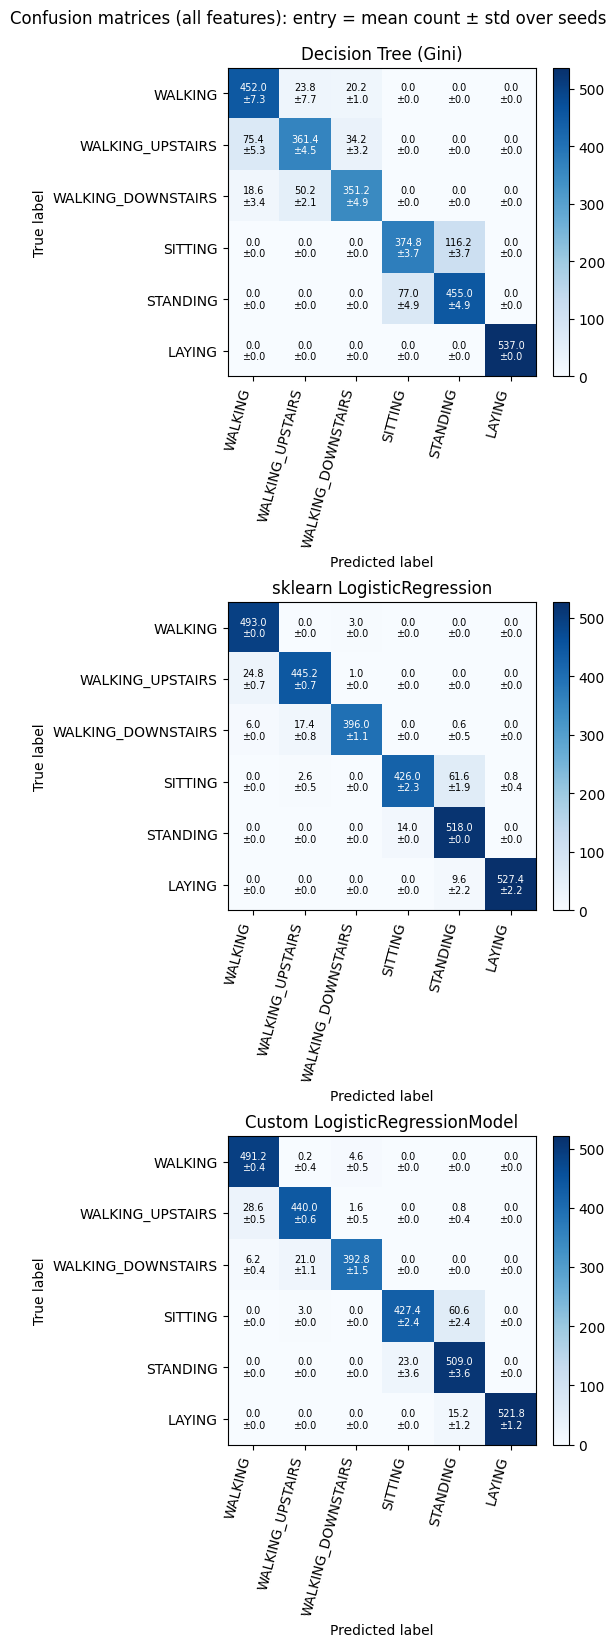

In [5]:
# Mean ± std over seeds (all features): per-class metrics + confusion matrices
label_order = activity_labels["activity_name"].to_list()
scenario = "full"

for model_name, pred_list in [
    ("DecisionTree (Gini)", PRED_RUNS[scenario]["DecisionTree (Gini)"]),
    ("sklearn LogisticRegression", PRED_RUNS[scenario]["sklearn LogisticRegression"]),
    ("Custom LogisticRegressionModel", PRED_RUNS[scenario]["Custom LogisticRegressionModel"]),
]:
    print("=" * 72)
    print(model_name, f"— mean ± std over {len(pred_list)} seeds (test set)")
    print("=" * 72)
    acc_runs = [accuracy_score(y_test_enc, p) for p in pred_list]
    print(
        f"accuracy: {np.mean(acc_runs):.4f} ± {np.std(acc_runs):.4f}\n"
    )
    pm, ps, rm, rs, fm, fs = per_class_prf_mean_std(y_test_enc, pred_list)
    tbl = pd.DataFrame(
        {
            "precision": [f"{m:.3f} ± {s:.3f}" for m, s in zip(pm, ps)],
            "recall": [f"{m:.3f} ± {s:.3f}" for m, s in zip(rm, rs)],
            "f1": [f"{m:.3f} ± {s:.3f}" for m, s in zip(fm, fs)],
        },
        index=target_names,
    )
    display(tbl)

fig, axes = plt.subplots(3, 1, figsize=(6, 16), constrained_layout=True)
for ax, (title, model_name) in zip(
    axes,
    [
        ("Decision Tree (Gini)", "DecisionTree (Gini)"),
        ("sklearn LogisticRegression", "sklearn LogisticRegression"),
        ("Custom LogisticRegressionModel", "Custom LogisticRegressionModel"),
    ],
):
    pred_list = PRED_RUNS[scenario][model_name]
    cm_mean, cm_std = confusion_mean_std(y_test_enc, pred_list)
    im = ax.imshow(cm_mean, cmap="Blues")
    ax.set_xticks(np.arange(len(label_order)), labels=label_order, rotation=75, ha="right")
    ax.set_yticks(np.arange(len(label_order)), labels=label_order)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            ax.text(
                j,
                i,
                f"{cm_mean[i, j]:.1f}\n±{cm_std[i, j]:.1f}",
                ha="center",
                va="center",
                color="black" if cm_mean[i, j] < cm_mean.max() * 0.65 else "white",
                fontsize=7,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
plt.suptitle(
    "Confusion matrices (all features): entry = mean count ± std over seeds",
    y=1.02,
)
plt.show()

## PCA scenario — mean ± std over seeds

PCA dimensionality and models are fit per seed in the experiment cell. Below: **per-class metrics** and **confusion matrices** aggregated over seeds (same as the full-feature section).


In [6]:
# PCA search metadata per seed (from experiment cell)
_pca_runs = globals().get("PCA_META_RUNS") or []
if _pca_runs:
    nc = [m["n_components"] for m in _pca_runs]
    va = [m["val_accuracy_probe"] for m in _pca_runs]
    print(
        "PCA n_components: mean=%.2f ± %.2f | probe val acc: mean=%.4f ± %.4f"
        % (np.mean(nc), np.std(nc), np.mean(va), np.std(va))
    )
else:
    print("Run the experiment cell above first (PCA_META_RUNS empty).")



PCA n_components: mean=67.00 ± 0.00 | probe val acc: mean=0.9562 ± 0.0025


In [7]:
# Test-set metrics for the PCA scenario are in `summary_agg` (scenario == "pca") in the experiment cell.

DecisionTree (Gini) (PCA) — mean ± std over 5 seeds
accuracy: 0.7615 ± 0.0024



,precision,recall,f1
WALKING,0.746 ± 0.009,0.838 ± 0.008,0.789 ± 0.003
WALKING_UPSTAIRS,0.790 ± 0.018,0.732 ± 0.009,0.760 ± 0.011
WALKING_DOWNSTAIRS,0.703 ± 0.007,0.661 ± 0.007,0.682 ± 0.002
SITTING,0.650 ± 0.006,0.684 ± 0.014,0.667 ± 0.006
STANDING,0.718 ± 0.009,0.750 ± 0.004,0.734 ± 0.006
LAYING,0.970 ± 0.005,0.877 ± 0.009,0.921 ± 0.004


sklearn LogisticRegression (PCA) — mean ± std over 5 seeds
accuracy: 0.9247 ± 0.0012



,precision,recall,f1
WALKING,0.913 ± 0.003,0.976 ± 0.002,0.944 ± 0.002
WALKING_UPSTAIRS,0.911 ± 0.003,0.894 ± 0.003,0.903 ± 0.001
WALKING_DOWNSTAIRS,0.956 ± 0.002,0.902 ± 0.005,0.928 ± 0.002
SITTING,0.893 ± 0.004,0.862 ± 0.002,0.877 ± 0.003
STANDING,0.881 ± 0.002,0.912 ± 0.006,0.896 ± 0.004
LAYING,0.998 ± 0.000,0.991 ± 0.003,0.995 ± 0.001


Custom LogisticRegressionModel (PCA) — mean ± std over 5 seeds
accuracy: 0.9224 ± 0.0012



,precision,recall,f1
WALKING,0.909 ± 0.002,0.973 ± 0.001,0.940 ± 0.001
WALKING_UPSTAIRS,0.899 ± 0.001,0.896 ± 0.001,0.897 ± 0.001
WALKING_DOWNSTAIRS,0.957 ± 0.001,0.887 ± 0.003,0.921 ± 0.002
SITTING,0.895 ± 0.001,0.860 ± 0.004,0.877 ± 0.002
STANDING,0.881 ± 0.004,0.921 ± 0.002,0.901 ± 0.001
LAYING,0.998 ± 0.000,0.986 ± 0.001,0.992 ± 0.001


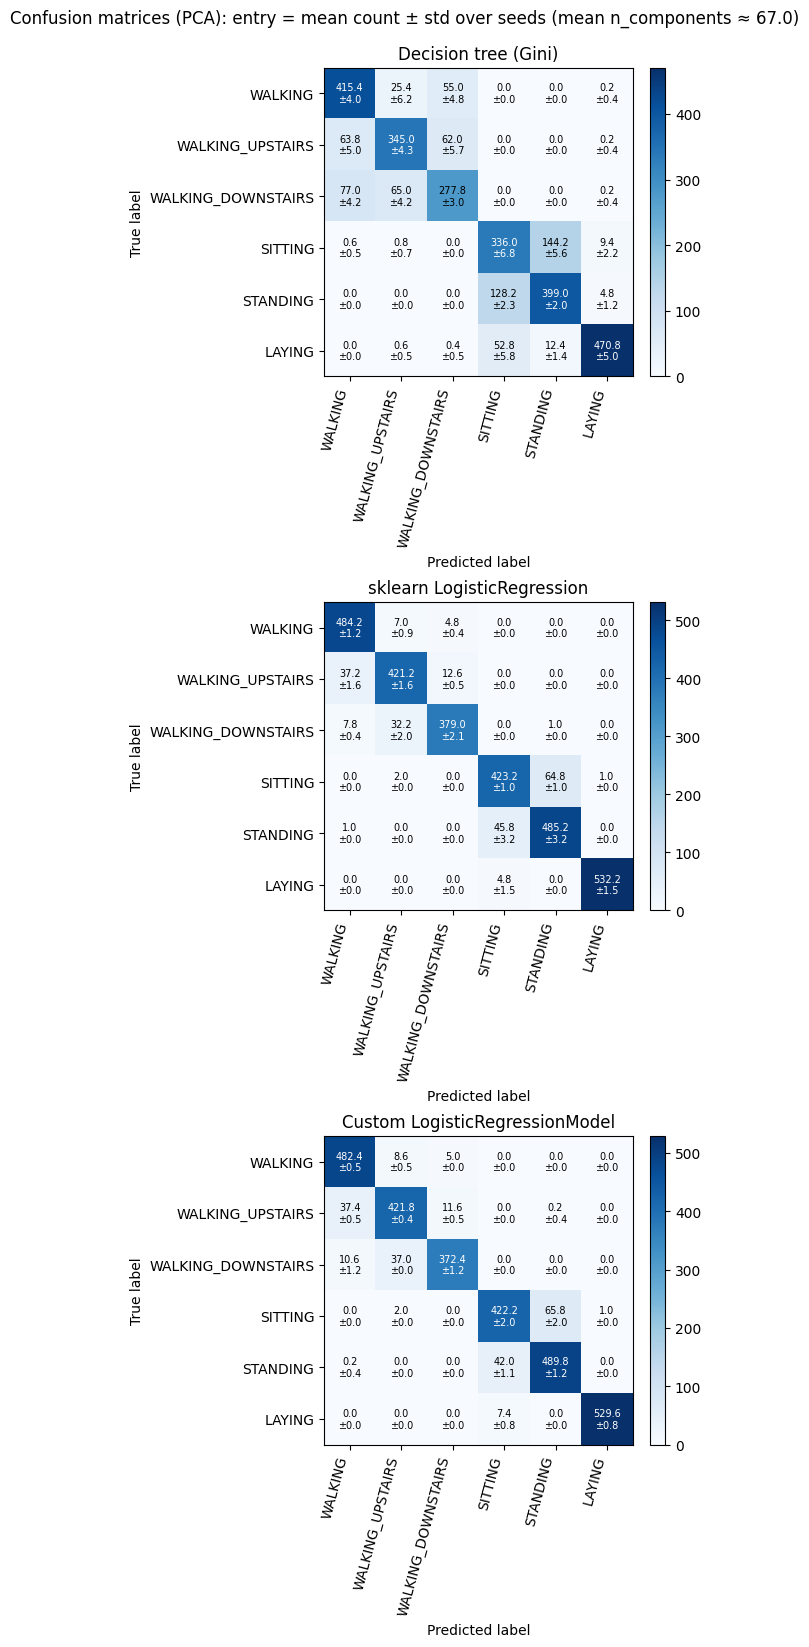

In [8]:
# Mean ± std over seeds (PCA-reduced features)
label_order = activity_labels["activity_name"].to_list()
scenario = "pca"

for model_name, pred_list in [
    ("DecisionTree (Gini)", PRED_RUNS[scenario]["DecisionTree (Gini)"]),
    ("sklearn LogisticRegression", PRED_RUNS[scenario]["sklearn LogisticRegression"]),
    ("Custom LogisticRegressionModel", PRED_RUNS[scenario]["Custom LogisticRegressionModel"]),
]:
    print("=" * 72)
    print(model_name, f"(PCA) — mean ± std over {len(pred_list)} seeds")
    print("=" * 72)
    acc_runs = [accuracy_score(y_test_enc, p) for p in pred_list]
    print(
        f"accuracy: {np.mean(acc_runs):.4f} ± {np.std(acc_runs):.4f}\n"
    )
    pm, ps, rm, rs, fm, fs = per_class_prf_mean_std(y_test_enc, pred_list)
    tbl = pd.DataFrame(
        {
            "precision": [f"{m:.3f} ± {s:.3f}" for m, s in zip(pm, ps)],
            "recall": [f"{m:.3f} ± {s:.3f}" for m, s in zip(rm, rs)],
            "f1": [f"{m:.3f} ± {s:.3f}" for m, s in zip(fm, fs)],
        },
        index=target_names,
    )
    display(tbl)

fig, axes = plt.subplots(3, 1, figsize=(6, 16), constrained_layout=True)
for ax, (title, model_name) in zip(
    axes,
    [
        ("Decision tree (Gini)", "DecisionTree (Gini)"),
        ("sklearn LogisticRegression", "sklearn LogisticRegression"),
        ("Custom LogisticRegressionModel", "Custom LogisticRegressionModel"),
    ],
):
    pred_list = PRED_RUNS[scenario][model_name]
    cm_mean, cm_std = confusion_mean_std(y_test_enc, pred_list)
    im = ax.imshow(cm_mean, cmap="Blues")
    ax.set_xticks(np.arange(len(label_order)), labels=label_order, rotation=75, ha="right")
    ax.set_yticks(np.arange(len(label_order)), labels=label_order)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            ax.text(
                j,
                i,
                f"{cm_mean[i, j]:.1f}\n±{cm_std[i, j]:.1f}",
                ha="center",
                va="center",
                color="black" if cm_mean[i, j] < cm_mean.max() * 0.65 else "white",
                fontsize=7,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
_pca_runs = globals().get("PCA_META_RUNS") or []
_nc = np.mean([m["n_components"] for m in _pca_runs]) if _pca_runs else float("nan")
plt.suptitle(
    "Confusion matrices (PCA): entry = mean count ± std over seeds "
    f"(mean n_components ≈ {_nc:.1f})",
    y=1.02,
)
plt.show()
